In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from load_dp import load_dp
from distributions import MinMaxBinning

In [3]:
num_qubits = 3
nbins = 2**num_qubits
dp = load_dp((20000, 21000), 'h', 250_000)

Found 1 files
['/home/fredo/qgan-lamarr/LamarrTraining.root']
Data loaded


(array([   7.,   19.,   35., 1664., 2134.,   58.,   14.,    8.]),
 array([-980.4921875 , -735.88745117, -491.28271484, -246.67797852,
          -2.07324219,  242.53149414,  487.13623047,  731.7409668 ,
         976.34570312]),
 <BarContainer object of 8 artists>)

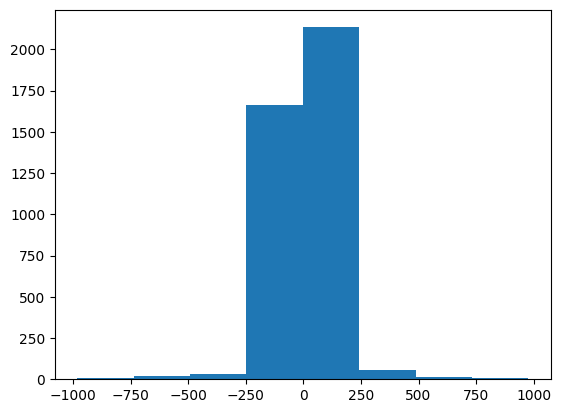

In [4]:
dpr = dp.loc[lambda x : (x <= 1000) & (x >= -1000)]
plt.hist(dpr, bins = nbins)

In [5]:
def sample_dist(_size, _nbins):
    _sample = np.random.choice(dpr, size = _size, replace=True)
    return MinMaxBinning(_sample, _nbins)

In [6]:
len(dpr)

3939

# QGAN evaluation

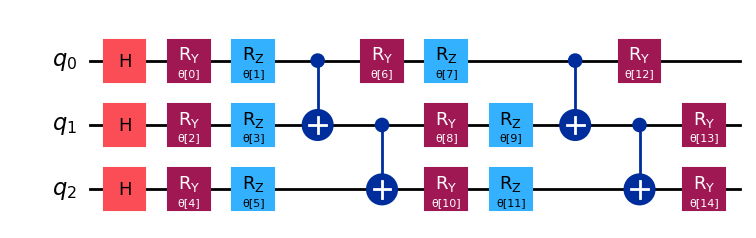

In [19]:
from qiskit.circuit import ParameterVector

reps = 2
qc = QuantumCircuit(num_qubits)
qc.h(range(num_qubits))
theta = ParameterVector("θ", length=(reps + 1) * num_qubits * 2)

p = 0
for r in range(reps + 1):
    for q in range(num_qubits):
        qc.ry(theta[p], q)
        p += 1

        if r < reps:
            qc.rz(theta[p], q)
            p += 1
        
    if r < reps:
        for q in range(num_qubits - 1):
            qc.cx(q, q + 1)

qc.draw("mpl")


In [20]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, InputLayer


discriminator = Sequential([InputLayer(shape=(nbins,)),
                            Dense(32, activation='tanh'),
                            Dense(64, activation='tanh'),
                            Dense(32, activation='tanh'),
                            Dense(1, activation='sigmoid')
                            ])
discriminator.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,513 (17.63 KB)

 Trainable params: 4,513 (17.63 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
from qgan import QGAN
model = QGAN(num_qubits =int(np.log2(nbins)),
             generator = qc,
             discriminator = discriminator,
             real_dist = sample_dist)

In [22]:
epochs = 2000
model.fit(epochs = epochs, shots = 2**10, manager = True, opt = 'ADAM_PSR', lr = 1e-2)

Monitoring run: run_20260310_010750
Training started


100%|██████████| 2000/2000 [10:34<00:00,  3.15it/s]

Training completed


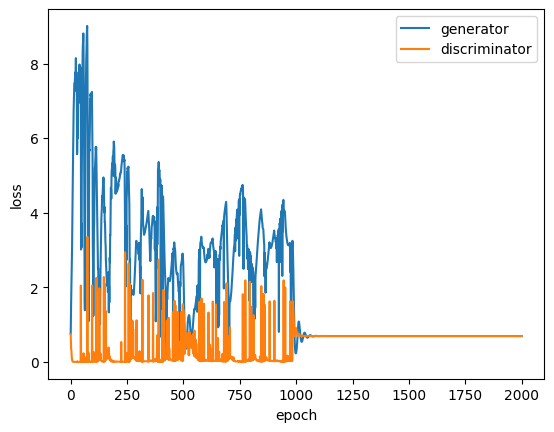

In [23]:
plt.plot(model.generator_losses, label = 'generator')
plt.plot(model.discriminator_losses, label = 'discriminator')
plt.legend()
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

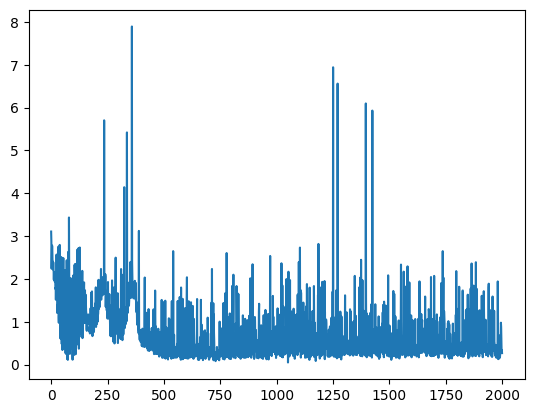

In [26]:
plt.plot(model.metrics['kullback_leibler'])

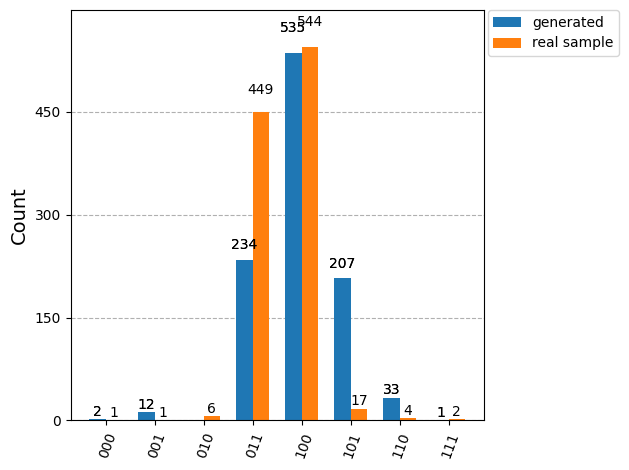

In [48]:
nsamples = 2**10
gen_res = model.get_sample(nsamples)
real_res = sample_dist(nsamples, nbins)
plot_histogram([gen_res, real_res], legend = ["generated","real sample"])